In [86]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



In [87]:
# load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"
df = pd.read_csv(url)

In [88]:
df.head(4)

,842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,...,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
0,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [89]:
# rename columns based on wdbc.names
columns = [
	'id_number',
	'diagnosis', # M = malignant, B = benign
]

stat_map = {
	0:'mean', 
	1:'standard_error', 
	2:'worst'
}

features = {
	0:'radius', 
	1:'texture', 
	2:'perimeter', 
	3:'area', 
	4:'smoothness', 
	5:'compactness',
	6:'concavity',
	7:'concave_points',
	8:'symmetry',
	9:'fractal_dimension'
}

other_columns = [stat_map[i] + '_' + features[j] for i in range(3) for j in range(10)]

columns.extend(other_columns)

df.columns = columns

From wdbc.names, explanation of columns

Ten real-valued features are computed for each cell nucleus:

	a) radius (mean of distances from center to points on the perimeter)
	b) texture (standard deviation of gray-scale values)
	c) perimeter
	d) area
	e) smoothness (local variation in radius lengths)
	f) compactness (perimeter^2 / area - 1.0)
	g) concavity (severity of concave portions of the contour)
	h) concave points (number of concave portions of the contour)
	i) symmetry 
	j) fractal dimension ("coastline approximation" - 1)

The mean, standard error, and "worst" or largest (mean of the three
largest values) of these features were computed for each image,
resulting in 30 features.  For instance, field 3 is Mean Radius, field
13 is Radius SE, field 23 is Worst Radius.

In [90]:
df.head()

,id_number,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
4,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


In [91]:
# convert 'diagnosis' column to binary
diagnosis = df['diagnosis']
diagnosis = diagnosis.map({"M": 1, "B": 0})

df['diagnosis'] = diagnosis

In [92]:
df

,id_number,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
1,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
2,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
3,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
4,843786,1,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.470,23.75,103.40,741.6,0.17910,0.52490,0.5355,0.1741,0.3985,0.12440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
563,926424,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
564,926682,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
565,926954,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
566,927241,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [93]:
# train test split
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2
)

In [94]:
X_train

,id_number,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
53,857438,15.10,22.02,97.26,712.8,0.09056,0.07081,0.052530,0.033340,0.1616,...,18.10,31.69,117.70,1030.0,0.13890,0.20570,0.27120,0.15300,0.2675,0.07873
162,8712064,12.34,22.22,79.85,464.5,0.10120,0.10150,0.053700,0.028220,0.1551,...,13.58,28.68,87.36,553.0,0.14520,0.23380,0.16880,0.08194,0.2268,0.09082
521,91789,11.26,19.83,71.30,388.1,0.08511,0.04413,0.005067,0.005664,0.1637,...,11.93,26.43,76.38,435.9,0.11080,0.07723,0.02533,0.02832,0.2557,0.07613
323,89511501,12.20,15.21,78.01,457.9,0.08673,0.06545,0.019940,0.016920,0.1638,...,13.75,21.38,91.11,583.1,0.12560,0.19280,0.11670,0.05556,0.2661,0.07961
496,914580,12.47,17.31,80.45,480.1,0.08928,0.07630,0.036090,0.023690,0.1526,...,14.06,24.34,92.82,607.3,0.12760,0.25060,0.20280,0.10530,0.3035,0.07661
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
407,90524101,17.99,20.66,117.80,991.7,0.10360,0.13040,0.120100,0.088240,0.1992,...,21.08,25.41,138.10,1349.0,0.14820,0.37350,0.33010,0.19740,0.3060,0.08503
381,90250,12.05,22.72,78.75,447.8,0.06935,0.10730,0.079430,0.029780,0.1203,...,12.57,28.71,87.36,488.4,0.08799,0.32140,0.29120,0.10920,0.2191,0.09349
56,857793,14.71,21.59,95.55,656.9,0.11370,0.13650,0.129300,0.081230,0.2027,...,17.87,30.70,115.70,985.5,0.13680,0.42900,0.35870,0.18340,0.3698,0.10940
80,8611161,13.34,15.86,86.49,520.0,0.10780,0.15350,0.116900,0.069870,0.1942,...,15.53,23.19,96.66,614.9,0.15360,0.47910,0.48580,0.17080,0.3527,0.10160


In [95]:
# check for missing values
X_train.isna().sum()

,0
id_number,0
mean_radius,0
mean_texture,0
mean_perimeter,0
mean_area,0
mean_smoothness,0
mean_compactness,0
mean_concavity,0
mean_concave_points,0
mean_symmetry,0


In [96]:
# standardize columns of training data
scaler = StandardScaler().set_output(transform="pandas")
X_train = scaler.fit_transform(X_train)

X_train.columns = ['id_number'] + other_columns
X_train

,id_number,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
53,-0.224085,0.326206,0.665924,0.267466,0.215928,-0.405012,-0.604688,-0.425968,-0.366942,-0.724287,...,0.437831,1.016771,0.370173,0.326212,0.300318,-0.280602,0.018626,0.637153,-0.365540,-0.284333
162,-0.161615,-0.477563,0.711689,-0.467997,-0.519112,0.370606,-0.012785,-0.411245,-0.500939,-0.962578,...,-0.533810,0.529481,-0.571229,-0.563576,0.578502,-0.100883,-0.480152,-0.469074,-1.026883,0.380074
521,-0.230175,-0.792081,0.164799,-0.829181,-0.745278,-0.802297,-1.119253,-1.023215,-1.091260,-0.647301,...,-0.888502,0.165228,-0.911921,-0.782013,-0.940472,-1.102254,-1.178976,-1.303803,-0.557281,-0.427216
323,0.481008,-0.518334,-0.892370,-0.545725,-0.538650,-0.684205,-0.708064,-0.836062,-0.796675,-0.643635,...,-0.497266,-0.652318,-0.454872,-0.507428,-0.286960,-0.363106,-0.733925,-0.879745,-0.388289,-0.235973
496,-0.223631,-0.439704,-0.411839,-0.442651,-0.472932,-0.498319,-0.498805,-0.632839,-0.619495,-1.054228,...,-0.430627,-0.173123,-0.401814,-0.462286,-0.198647,0.006564,-0.314542,-0.105417,0.219433,-0.400838
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
407,0.489061,1.167834,0.354723,1.135152,1.041552,0.545557,0.544596,0.424294,1.069866,0.654133,...,1.078426,0.000100,1.003152,0.921270,0.710970,0.792592,0.305520,1.328350,0.260056,0.061884
381,-0.230187,-0.562017,0.826102,-0.514465,-0.568549,-1.951143,0.099077,-0.087474,-0.460112,-2.238350,...,-0.750924,0.534338,-0.571229,-0.684080,-1.947675,0.459378,0.116043,-0.044704,-1.152002,0.526804
56,-0.224083,0.212630,0.567530,0.195229,0.050448,1.281810,0.662244,0.540062,0.886405,0.782443,...,0.388389,0.856499,0.308116,0.243203,0.207590,1.147552,0.444827,1.110405,1.296757,1.401139
80,-0.162418,-0.186342,-0.743634,-0.187499,-0.354816,0.851722,0.990115,0.384028,0.589098,0.470832,...,-0.114628,-0.359297,-0.282665,-0.448109,0.949414,1.467975,1.063915,0.914254,1.018895,0.972489


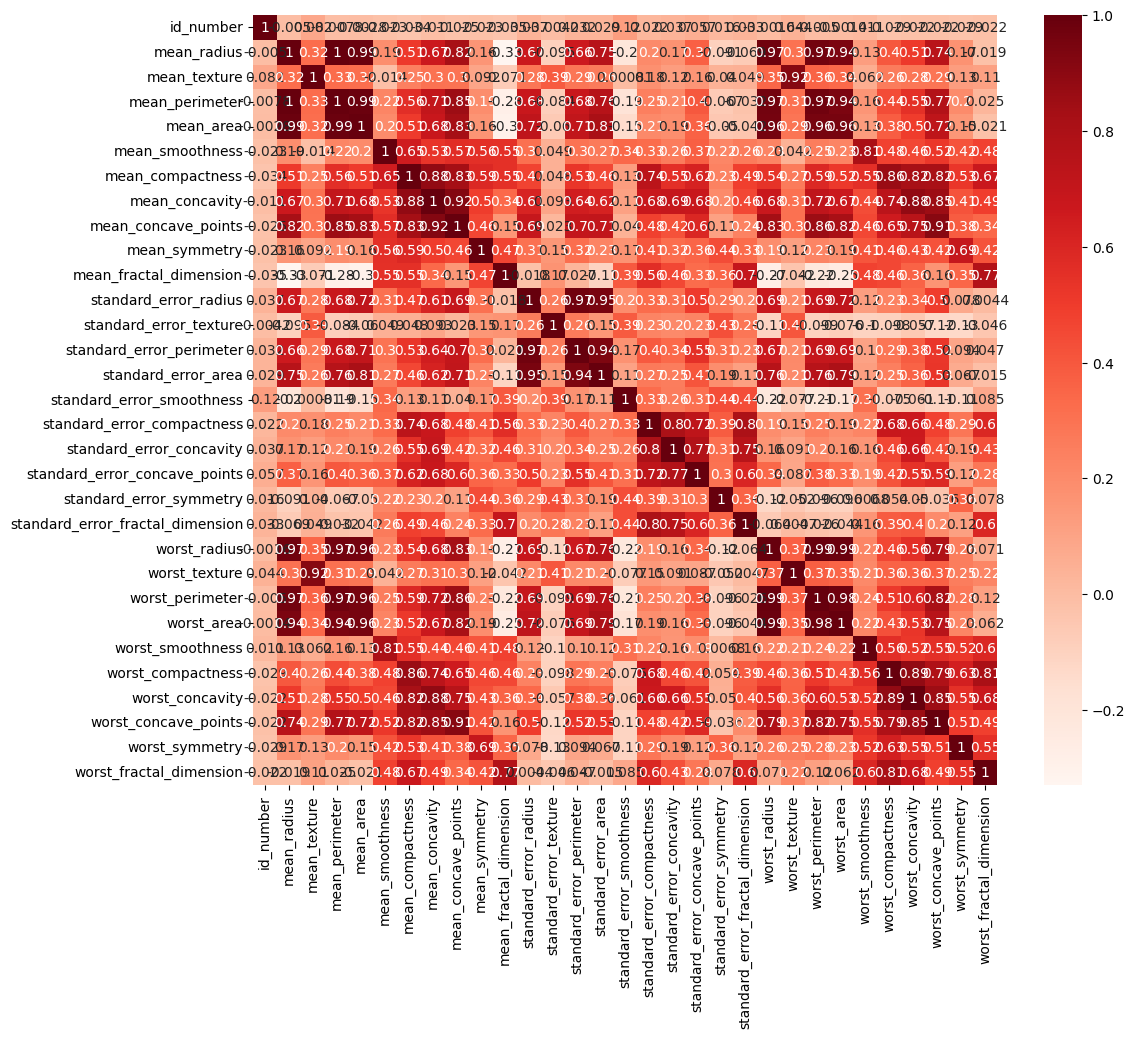

In [97]:
# plot correlation matrix
plt.figure(figsize=(12,10))
corr_matrix = X_train.corr()
sns.heatmap(corr_matrix, annot=True, cmap=plt.cm.Reds)
plt.show()

In [98]:
# drop highly correlated features
corr_matrix = corr_matrix.abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
X_train_light = X_train.drop(to_drop, axis=1)
print(f"Dropped {len(to_drop)} features: {to_drop}")

Dropped 10 features: ['mean_perimeter', 'mean_area', 'mean_concave_points', 'standard_error_perimeter', 'standard_error_area', 'worst_radius', 'worst_texture', 'worst_perimeter', 'worst_area', 'worst_concave_points']


In [99]:
# predict using logistic regression
X_test_standardized = scaler.transform(X_test)
X_test_light = X_test_standardized.drop(columns=to_drop)

model = LogisticRegression()
model.fit(X_train_light, y_train)
prediction = model.predict(X_test_light)

In [100]:
X_test_light.columns

Index(['id_number', 'mean_radius', 'mean_texture', 'mean_smoothness',
       'mean_compactness', 'mean_concavity', 'mean_symmetry',
       'mean_fractal_dimension', 'standard_error_radius',
       'standard_error_texture', 'standard_error_smoothness',
       'standard_error_compactness', 'standard_error_concavity',
       'standard_error_concave_points', 'standard_error_symmetry',
       'standard_error_fractal_dimension', 'worst_smoothness',
       'worst_compactness', 'worst_concavity', 'worst_symmetry',
       'worst_fractal_dimension'],
      dtype='object')

In [101]:
model.coef_

array([[ 0.03138836,  2.21134261,  1.2172163 ,  0.12482023, -0.07048305,
         1.53720384, -0.17097623, -0.9724613 ,  2.13062396,  0.13177155,
         0.11151215, -0.65029855, -0.52601912,  0.60585142, -0.75444373,
        -0.60902851,  0.80206419,  0.22228255,  1.07257286,  1.00889322,
         0.72694252]])

In [102]:
model_coef_weights = pd.DataFrame({
    'feature':X_test_light.columns,
    'model_coefficient':model.coef_.flatten()
})

model_coef_weights

,feature,model_coefficient
0,id_number,0.031388
1,mean_radius,2.211343
2,mean_texture,1.217216
3,mean_smoothness,0.124820
4,mean_compactness,-0.070483
5,mean_concavity,1.537204
6,mean_symmetry,-0.170976
7,mean_fractal_dimension,-0.972461
8,standard_error_radius,2.130624
9,standard_error_texture,0.131772


mean_radius is the most important feature in determining whether a tumor is malignant

In [103]:
# accuracy
accuracy = (y_test == prediction).mean()
accuracy

np.float64(0.9649122807017544)

In [104]:
def confusion_matrix_and_recall(test_labels, model_predictions):
    cm = cm = confusion_matrix(test_labels, model_predictions)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
    disp.plot(cmap='Blues')
    plt.show()

    true_positives = cm[1,1]
    false_positives = cm[0,1]
    false_negatives = cm[1,0]
    true_negatives = cm[0,0]

    actual_positives = true_positives + false_negatives
    actual_negatives = false_positives + true_negatives

    recall = true_positives / (actual_positives)
    print('recall:', recall)


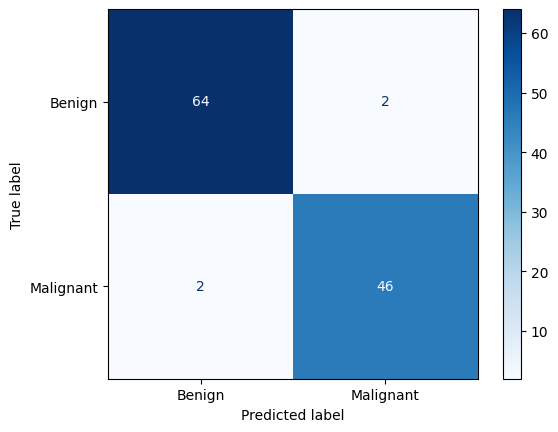

recall: 0.9583333333333334


In [105]:
confusion_matrix_and_recall(y_test, prediction)

recall can be higher by adjusting threshold of when the model predicts a tumor as being malignant

use precision-recall curve to choose best threshold

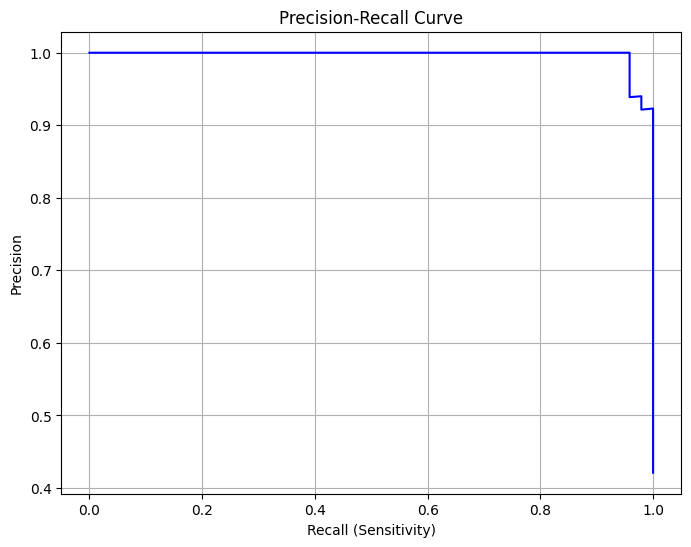

In [109]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_test, probs)

plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, color='blue', label='Logistic Regression')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

In [110]:
# Find the threshold where recall is at least 95%
target_recall = 0.95
idx = (recalls >= target_recall).argmin() - 1 
best_threshold = thresholds[idx]

print(f"To get {target_recall*100}% recall, use a threshold of: {best_threshold:.4f}")

To get 95.0% recall, use a threshold of: 0.7716


In [113]:
# adjust threshold
probability_threshold = 1 - 0.7716
probs = model.predict_proba(X_test_light)[:, 1]
prediction_low_threshold = (probs > probability_threshold).astype(int)

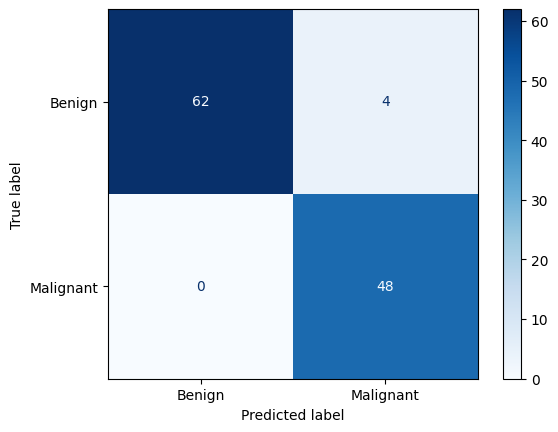

recall: 1.0


In [114]:
confusion_matrix_and_recall(y_test, prediction_low_threshold)